# 03. Model Preparation and Baseline Model

This notebook prepares the cleaned diabetes readmission dataset for machine learning and builds the first baseline model for predicting 30-day hospital readmission.

The goal of this notebook is to create a complete, reproducible modeling foundation using a leakage-safe preprocessing and modeling pipeline.

The target variable is `readmitted_30_days`:

- `1`: patient was readmitted within 30 days
- `0`: patient was not readmitted within 30 days

Since 30-day readmissions are less frequent than non-readmissions, this is an imbalanced healthcare classification problem. Therefore, model evaluation will focus not only on accuracy, but also precision, recall, F1-score, confusion matrix, and ROC-AUC.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

import joblib

## Load Preprocessed Dataset

The cleaned dataset was created in `02_data_preprocessing.ipynb` and saved to `data/processed/diabetic_data_preprocessed.csv`.

Since the `data/processed/` folder is ignored by Git, the processed CSV may not appear in the GitHub repository. If this file is missing, rerun `02_data_preprocessing.ipynb` to regenerate it.

In [2]:
data_path = "../data/processed/diabetic_data_preprocessed.csv"

df = pd.read_csv(data_path)

df.head()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,medical_specialty_grouped,readmitted_30_days
0,Caucasian,Female,[0-10),6,25,1,1,41,0,1,...,No,No,No,No,No,No,No,No,Other,0
1,Caucasian,Female,[10-20),1,1,7,3,59,0,18,...,Up,No,No,No,No,No,Ch,Yes,Unknown,0
2,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,...,No,No,No,No,No,No,No,Yes,Unknown,0
3,Caucasian,Male,[30-40),1,1,7,2,44,1,16,...,Up,No,No,No,No,No,Ch,Yes,Unknown,0
4,Caucasian,Male,[40-50),1,1,7,1,51,0,8,...,Steady,No,No,No,No,No,Ch,Yes,Unknown,0


In [3]:
df.shape

(101766, 44)

## Basic Dataset Validation

Before modeling, basic validation checks are performed to confirm that the dataset has loaded correctly and contains the expected target column.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 44 columns):
 #   Column                     Non-Null Count   Dtype
---  ------                     --------------   -----
 0   race                       101766 non-null  str  
 1   gender                     101766 non-null  str  
 2   age                        101766 non-null  str  
 3   admission_type_id          101766 non-null  int64
 4   discharge_disposition_id   101766 non-null  int64
 5   admission_source_id        101766 non-null  int64
 6   time_in_hospital           101766 non-null  int64
 7   num_lab_procedures         101766 non-null  int64
 8   num_procedures             101766 non-null  int64
 9   num_medications            101766 non-null  int64
 10  number_outpatient          101766 non-null  int64
 11  number_emergency           101766 non-null  int64
 12  number_inpatient           101766 non-null  int64
 13  diag_1                     101766 non-null  str  
 14  diag_2         

In [5]:
df.isna().sum().sort_values(ascending=False).head(10)

race                        0
gender                      0
age                         0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
num_lab_procedures          0
num_procedures              0
num_medications             0
dtype: int64

In [6]:
df["readmitted_30_days"].value_counts()

readmitted_30_days
0    90409
1    11357
Name: count, dtype: int64

In [7]:
df["readmitted_30_days"].value_counts(normalize=True)

readmitted_30_days
0    0.888401
1    0.111599
Name: proportion, dtype: float64

The target distribution confirms that this is an imbalanced classification problem. Most patients were not readmitted within 30 days, while a smaller percentage were readmitted within 30 days.

Because of this imbalance, accuracy alone can be misleading. A model could achieve high accuracy by mostly predicting the majority class. Therefore, recall, precision, F1-score, confusion matrix, and ROC-AUC are used for evaluation.

## Separate Features and Target

The feature matrix `X` contains all input variables used for prediction.

The target variable `y` contains the binary 30-day readmission outcome.

In [8]:
X = df.drop(columns=["readmitted_30_days"])
y = df["readmitted_30_days"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (101766, 43)
Target shape: (101766,)


## Identify Categorical and Numerical Features

Categorical variables will be one-hot encoded, while numerical variables will be scaled.

Although `admission_type_id`, `discharge_disposition_id`, and `admission_source_id` are stored as numeric values, they represent categorical hospital coding systems rather than continuous measurements. These variables will therefore be treated as categorical features and one-hot encoded.

The preprocessing will be handled inside a scikit-learn pipeline to avoid data leakage.

In [9]:

categorical_id_cols = [
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id"
]

categorical_cols = X.select_dtypes(
    include=["object", "string"]
).columns.tolist()

categorical_cols = categorical_cols + categorical_id_cols

numerical_cols = [
    col for col in X.select_dtypes(
        include=["int64", "float64"]
    ).columns.tolist()
    if col not in categorical_id_cols
]

print("Number of categorical columns:", len(categorical_cols))
print("Number of numerical columns:", len(numerical_cols))

Number of categorical columns: 35
Number of numerical columns: 8


## Train-Test Split

The dataset is split into training and test sets.

A stratified split is used so that both sets preserve the same proportion of 30-day readmitted and non-readmitted patients.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Test feature shape:", X_test.shape)
print("Training target distribution:")
print(y_train.value_counts(normalize=True))
print("Test target distribution:")
print(y_test.value_counts(normalize=True))

Training feature shape: (81412, 43)
Test feature shape: (20354, 43)
Training target distribution:
readmitted_30_days
0    0.888395
1    0.111605
Name: proportion, dtype: float64
Test target distribution:
readmitted_30_days
0    0.888425
1    0.111575
Name: proportion, dtype: float64


## Preprocessing Pipeline

The preprocessing pipeline applies:

- Standard scaling to numerical features
- One-hot encoding to categorical features

Using `handle_unknown="ignore"` prevents errors if new categories appear in the test data.

In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

## Baseline Model: Logistic Regression

Logistic Regression is used as the baseline model because it is simple, interpretable, and commonly used for binary classification.

Since the target is imbalanced, `class_weight="balanced"` is used so that the minority class receives more weight during training.

In [12]:
baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

### Handling Class Imbalance

The target variable is imbalanced, with only about 11% of patients readmitted within 30 days.

To address this, the Logistic Regression model uses `class_weight="balanced"`. This gives higher weight to the minority class during training, helping the model pay more attention to readmitted patients.

This approach keeps the pipeline simple and avoids resampling the dataset at this stage. More advanced balancing methods such as SMOTE can be tested later.

In [13]:
baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

## Model Predictions

The model produces both class predictions and predicted probabilities.

Predicted probabilities are useful for ROC-AUC evaluation and future threshold tuning.

In [14]:
y_pred = baseline_model.predict(X_test)
y_proba = baseline_model.predict_proba(X_test)[:, 1]

## Baseline Model Evaluation

The model is evaluated using multiple metrics because this is an imbalanced healthcare classification problem.

Accuracy shows overall correctness, but precision, recall, F1-score, confusion matrix, and ROC-AUC provide a more complete view of model performance.

In [15]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Score": [accuracy, precision, recall, f1, roc_auc]
})

metrics_df

,Metric,Score
0,Accuracy,0.660804
1,Precision,0.179997
2,Recall,0.573756
3,F1-score,0.274027
4,ROC-AUC,0.670829


In [16]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.67      0.78     18083
           1       0.18      0.57      0.27      2271

    accuracy                           0.66     20354
   macro avg       0.55      0.62      0.53     20354
weighted avg       0.84      0.66      0.72     20354



## Confusion Matrix

The confusion matrix helps show where the model is making correct and incorrect predictions.

For this project, false negatives are especially important because they represent patients who were actually readmitted within 30 days but were predicted as not readmitted.

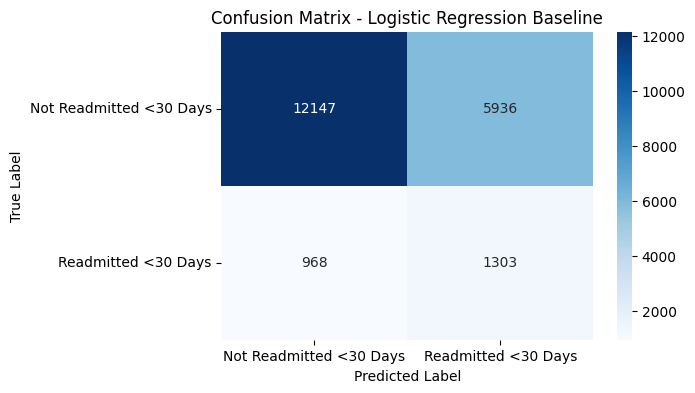

In [17]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Readmitted <30 Days", "Readmitted <30 Days"],
    yticklabels=["Not Readmitted <30 Days", "Readmitted <30 Days"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Logistic Regression Baseline")
plt.show()

## ROC Curve

The ROC curve shows how well the model separates readmitted and non-readmitted patients across different classification thresholds.

ROC-AUC is useful because it evaluates predicted probabilities rather than only the final class prediction.

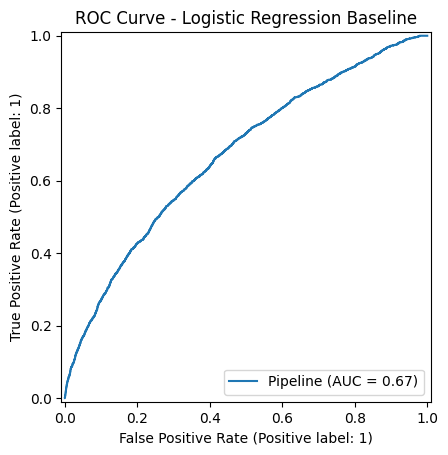

In [18]:
RocCurveDisplay.from_estimator(baseline_model, X_test, y_test)

plt.title("ROC Curve - Logistic Regression Baseline")
plt.show()

## Why Recall Is Important for 30-Day Readmission Prediction

In 30-day hospital readmission prediction, recall is especially important because the goal is to identify as many high-risk patients as possible.

A false negative means the model predicts that a patient is not likely to be readmitted, even though the patient actually is readmitted within 30 days. In a healthcare setting, this could mean missing an opportunity for early intervention, follow-up care, discharge planning, or additional monitoring.

Precision is also important because hospitals do not want to incorrectly flag too many low-risk patients. However, for an initial readmission risk screening model, recall is usually prioritized because missing high-risk patients can have greater clinical and operational consequences.

## Save Baseline Model Pipeline

The trained model pipeline is saved so it can be reused later without retraining.

The saved pipeline includes both preprocessing steps and the Logistic Regression model.

In [19]:
model_path = "../models/baseline_logistic_regression_pipeline.pkl"

joblib.dump(baseline_model, model_path)

print(f"Model saved to: {model_path}")

Model saved to: ../models/baseline_logistic_regression_pipeline.pkl


## Baseline Model Interpretation

The Logistic Regression baseline provides the first complete machine learning model for predicting 30-day readmission.

The model achieved:

- Accuracy: 0.6608
- Precision: 0.1800
- Recall: 0.5738
- F1-score: 0.2740
- ROC-AUC: 0.6708

Because this is an imbalanced healthcare classification problem, accuracy alone is not enough to judge the model. The model has moderate recall, meaning it identifies more than half of the actual 30-day readmission cases.

However, precision is low, which means many patients predicted as high-risk were not actually readmitted within 30 days. This is common in early healthcare risk models and can be improved later using threshold tuning, feature engineering, and model comparison.



## Summary

In this notebook, a complete baseline modeling pipeline was built for 30-day hospital readmission prediction.

Completed steps:

- Loaded the preprocessed diabetes dataset
- Validated the dataset and target distribution
- Separated features and target
- Identified categorical and numerical columns
- Created a leakage-safe preprocessing pipeline
- Applied one-hot encoding and numerical scaling
- Used a stratified train-test split
- Trained a Logistic Regression baseline model
- Evaluated the model using accuracy, precision, recall, F1-score, confusion matrix, and ROC-AUC
- Explained why recall is important in the healthcare readmission context
- Saved the trained model pipeline for later reuse

This notebook establishes the main modeling foundation for the project. Future work can focus on model comparison, threshold tuning, feature importance, and improving recall while monitoring precision.